# FX Client Flow Trading & Market Risk Simulator

### Python-based simulation of an FX flow trading desk

This project simulates institutional client FX flow, dealer pricing and positioning, partial hedging, mark-to-market P&L, market risk and stress testing across EUR/USD, GBP/USD and USD/JPY.

**Market data:** Federal Reserve Economic Data (FRED), January 2021 to December 2024.

**Client flow:** Synthetic institutional and corporate trades generated for simulation purposes.

**Risk framework:** Historical VaR, Expected Shortfall, residual FX exposure and adverse stress testing.

**Dashboard:** Power BI

## 1. Project Setup

In [122]:
# ============================================
# FX CLIENT FLOW TRADING & MARKET RISK PROJECT
# Cell 1: Project Setup
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from datetime import datetime

# Make results reproducible
np.random.seed(42)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Project environment ready.")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Project environment ready.
Pandas version: 2.2.3
NumPy version: 2.1.3


## 2. FX Market Data

Historical daily FX rates are obtained from FRED for EUR/USD, GBP/USD and USD/JPY over January 2021 to December 2024.

In [123]:
# ============================================
# CELL 2: DOWNLOAD HISTORICAL FX DATA
# ============================================

import pandas as pd

# FRED series
fred_series = {
    "EURUSD": "DEXUSEU",   # USD per EUR
    "GBPUSD": "DEXUSUK",   # USD per GBP
    "USDJPY": "DEXJPUS"    # JPY per USD
}

start_date = "2021-01-01"
end_date = "2024-12-31"

def download_fred_series(series_id):
    """
    Download a daily FX series from FRED.
    """

    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"

    df = pd.read_csv(url)

    df["observation_date"] = pd.to_datetime(
        df["observation_date"]
    )

    df = df.rename(
        columns={
            "observation_date": "Date",
            series_id: "Price"
        }
    )

    df["Price"] = pd.to_numeric(
        df["Price"],
        errors="coerce"
    )

    df = df[
        (df["Date"] >= start_date) &
        (df["Date"] <= end_date)
    ]

    return df


# Download each currency pair
fx_data = {}

for pair, series_id in fred_series.items():

    print(f"Downloading {pair}...")

    fx_data[pair] = download_fred_series(series_id)


print("\nDownload complete.")


Download complete.


In [124]:
# ============================================
# CELL 3: CREATE MASTER FX DATASET
# ============================================

# Start with EUR/USD
market_data = fx_data["EURUSD"][
    ["Date", "Price"]
].rename(
    columns={"Price": "EURUSD"}
)

# Add GBP/USD
market_data = market_data.merge(
    fx_data["GBPUSD"][["Date", "Price"]].rename(
        columns={"Price": "GBPUSD"}
    ),
    on="Date",
    how="outer"
)

# Add USD/JPY
market_data = market_data.merge(
    fx_data["USDJPY"][["Date", "Price"]].rename(
        columns={"Price": "USDJPY"}
    ),
    on="Date",
    how="outer"
)

# Sort chronologically
market_data = market_data.sort_values(
    "Date"
).reset_index(drop=True)

# Remove days where all three prices are missing
market_data = market_data.dropna(
    subset=["EURUSD", "GBPUSD", "USDJPY"],
    how="all"
)

print("Dataset shape:", market_data.shape)

display(market_data.head(10))

Dataset shape: (999, 4)


,Date,EURUSD,GBPUSD,USDJPY
1,2021-01-04,1.2254,1.3551,103.1900
2,2021-01-05,1.2295,1.3620,102.7000
3,2021-01-06,1.2290,1.3593,103.2500
4,2021-01-07,1.2265,1.3551,103.8400
5,2021-01-08,1.2252,1.3583,103.8900
6,2021-01-11,1.2169,1.3522,104.1600
7,2021-01-12,1.2168,1.3637,104.0900
8,2021-01-13,1.2159,1.3631,103.9100
9,2021-01-14,1.2156,1.3690,103.6600
10,2021-01-15,1.2099,1.3599,103.8000


In [125]:
# ============================================
# CELL 4: CALCULATE DAILY FX RETURNS
# ============================================

for pair in ["EURUSD", "GBPUSD", "USDJPY"]:

    market_data[f"{pair}_Return"] = (
        market_data[pair].pct_change()
    )

# Remove the first observation because
# it has no previous day's price
market_data_returns = market_data.dropna().copy()

print(
    "Observations available for risk analysis:",
    len(market_data_returns)
)

display(
    market_data_returns.head()
)

Observations available for risk analysis: 998


,Date,EURUSD,GBPUSD,USDJPY,EURUSD_Return,GBPUSD_Return,USDJPY_Return
2,2021-01-05,1.2295,1.3620,102.7000,0.0033,0.0051,-0.0047
3,2021-01-06,1.2290,1.3593,103.2500,-0.0004,-0.0020,0.0054
4,2021-01-07,1.2265,1.3551,103.8400,-0.0020,-0.0031,0.0057
5,2021-01-08,1.2252,1.3583,103.8900,-0.0011,0.0024,0.0005
6,2021-01-11,1.2169,1.3522,104.1600,-0.0068,-0.0045,0.0026


In [126]:
# ============================================
# CELL 5: CLEAN FX RETURN DATA
# ============================================

return_columns = [
    "EURUSD_Return",
    "GBPUSD_Return",
    "USDJPY_Return"
]

# Keep only observations where all three FX returns exist
risk_data = market_data.dropna(
    subset=return_columns
).copy()

print("Observations before cleaning:", len(market_data))
print("Observations after cleaning:", len(risk_data))
print("\nMissing values:")
display(risk_data[return_columns].isna().sum())

print("\nClean risk dataset:")
display(risk_data.head())

Observations before cleaning: 999
Observations after cleaning: 998

Missing values:


,0
EURUSD_Return,0
GBPUSD_Return,0
USDJPY_Return,0



Clean risk dataset:


,Date,EURUSD,GBPUSD,USDJPY,EURUSD_Return,GBPUSD_Return,USDJPY_Return
2,2021-01-05,1.2295,1.3620,102.7000,0.0033,0.0051,-0.0047
3,2021-01-06,1.2290,1.3593,103.2500,-0.0004,-0.0020,0.0054
4,2021-01-07,1.2265,1.3551,103.8400,-0.0020,-0.0031,0.0057
5,2021-01-08,1.2252,1.3583,103.8900,-0.0011,0.0024,0.0005
6,2021-01-11,1.2169,1.3522,104.1600,-0.0068,-0.0045,0.0026


In [127]:
# ============================================
# CELL 6: FX RETURN STATISTICS
# ============================================

summary_stats = risk_data[return_columns].describe().T

summary_stats["Annualised_Volatility"] = (
    risk_data[return_columns].std() * np.sqrt(252)
)

summary_stats["Annualised_Return"] = (
    risk_data[return_columns].mean() * 252
)

display(summary_stats)

,count,mean,std,min,25%,50%,75%,max,Annualised_Volatility,Annualised_Return
EURUSD_Return,998.0000,-0.0002,0.0047,-0.0174,-0.0027,-0.0002,0.0024,0.0189,0.0748,-0.0398
GBPUSD_Return,998.0000,-0.0001,0.0055,-0.0309,-0.0030,-0.0001,0.0030,0.0247,0.0872,-0.0162
USDJPY_Return,998.0000,0.0004,0.0063,-0.0423,-0.0023,0.0005,0.0037,0.0265,0.1005,0.1116


In [128]:
# ============================================
# CELL 7: FX CORRELATION
# ============================================

correlation_matrix = risk_data[return_columns].corr()

display(correlation_matrix)

,EURUSD_Return,GBPUSD_Return,USDJPY_Return
EURUSD_Return,1.0000,0.7664,-0.4442
GBPUSD_Return,0.7664,1.0000,-0.4109
USDJPY_Return,-0.4442,-0.4109,1.0000


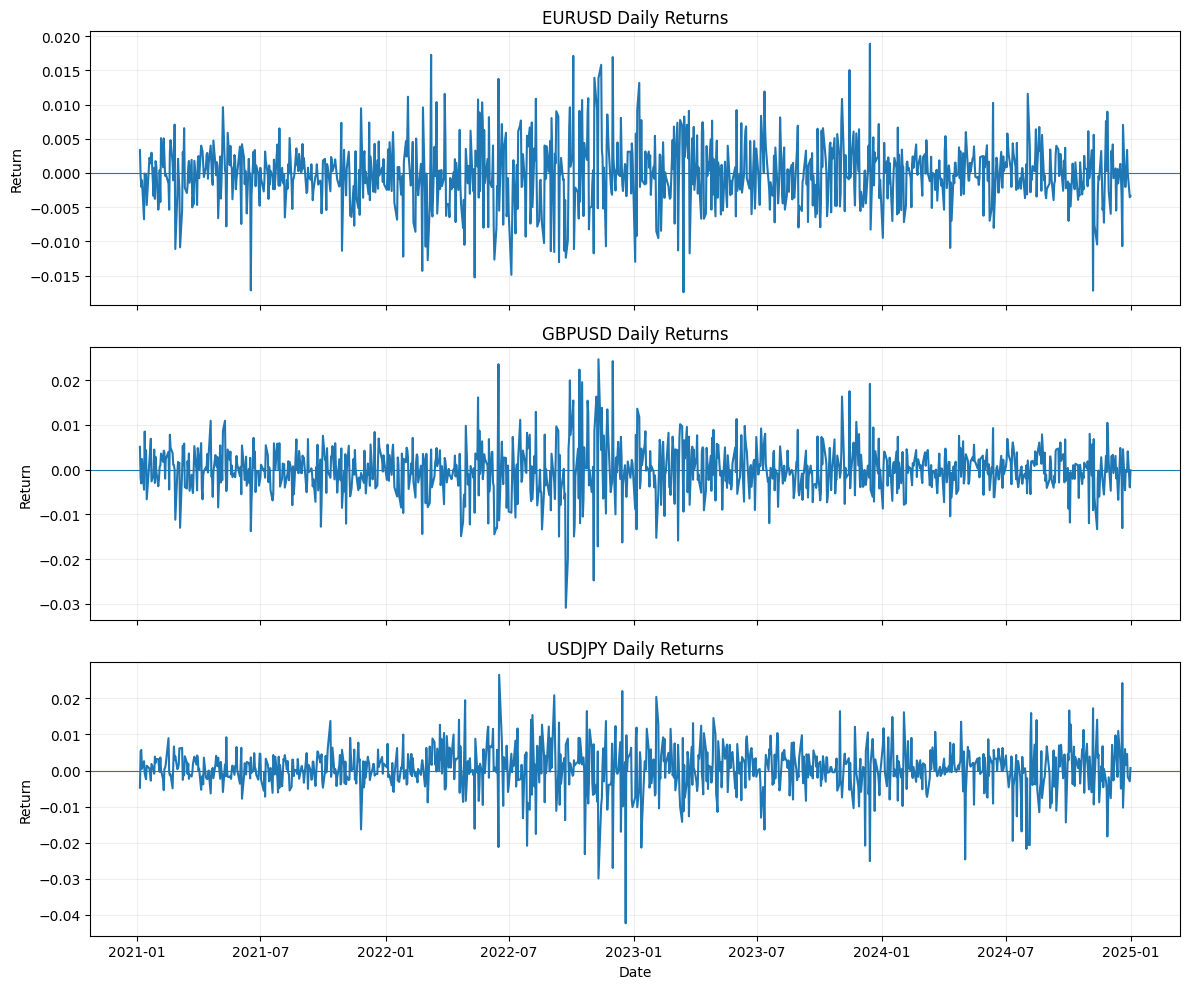

In [129]:
# ============================================
# CELL 8: FX RETURN DISTRIBUTIONS
# ============================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 10),
    sharex=True
)

pairs = ["EURUSD", "GBPUSD", "USDJPY"]

for ax, pair in zip(axes, pairs):

    ax.plot(
        risk_data["Date"],
        risk_data[f"{pair}_Return"]
    )

    ax.axhline(
        0,
        linewidth=0.8
    )

    ax.set_title(f"{pair} Daily Returns")
    ax.set_ylabel("Return")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 3. Synthetic Client Flow

Because institutional client trading blotters are proprietary, client activity is simulated rather than sourced from bank trading records.

The simulation represents four client segments:

- Asset Managers
- Hedge Funds
- Corporates
- Banks

Client probabilities, trade sizes and pair/side distributions are modelling assumptions rather than observed market data.

In [130]:
# ============================================
# CELL 9: CLIENT PROFILES
# ============================================

client_profiles = pd.DataFrame({
    "Client_Type": [
        "Asset Manager",
        "Hedge Fund",
        "Corporate",
        "Bank"
    ],

    # Probability determines how frequently
    # each client type appears in our simulation.
    "Probability": [
        0.35,
        0.20,
        0.30,
        0.15
    ],

    # Typical transaction size is the centre point
    # around which individual trade sizes will vary.
    "Typical_Trade_Size_USD": [
        8_000_000,
        5_000_000,
        10_000_000,
        15_000_000
    ]
})

# Check that probabilities add up to 100%
assert np.isclose(
    client_profiles["Probability"].sum(),
    1.0
)

display(client_profiles)

,Client_Type,Probability,Typical_Trade_Size_USD
0,Asset Manager,0.3500,8000000
1,Hedge Fund,0.2000,5000000
2,Corporate,0.3000,10000000
3,Bank,0.1500,15000000


In [131]:
# ============================================
# CELL 10: GENERATE SYNTHETIC CLIENT TRADES
# ============================================

np.random.seed(42)

N_TRADES = 1000

# Select trading dates from our real market dataset
trade_dates = np.random.choice(
    risk_data["Date"].values,
    size=N_TRADES,
    replace=True
)

# Select client type using the probabilities
# defined in Cell 9.
client_types = np.random.choice(
    client_profiles["Client_Type"],
    size=N_TRADES,
    p=client_profiles["Probability"]
)

# Select currency pairs
pairs = np.random.choice(
    ["EURUSD", "GBPUSD", "USDJPY"],
    size=N_TRADES,
    p=[0.50, 0.30, 0.20]
)

# Select Buy/Sell direction
sides = np.random.choice(
    ["Buy", "Sell"],
    size=N_TRADES
)

client_trades = pd.DataFrame({
    "Trade_ID": [
        f"FX{100000 + i}"
        for i in range(N_TRADES)
    ],

    "Date": pd.to_datetime(trade_dates),

    "Client_Type": client_types,

    "Pair": pairs,

    "Side": sides
})

client_trades = (
    client_trades
    .sort_values("Date")
    .reset_index(drop=True)
)

print("Number of simulated trades:", len(client_trades))

print("\nClient mix:")
display(
    client_trades["Client_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .rename("Percentage")
    .to_frame()
)

display(client_trades.head(10))

Number of simulated trades: 1000

Client mix:


,Percentage
Client_Type,
Asset Manager,35.5000
Corporate,29.6000
Hedge Fund,19.2000
Bank,15.7000


,Trade_ID,Date,Client_Type,Pair,Side
0,FX100895,2021-01-05,Asset Manager,GBPUSD,Sell
1,FX100367,2021-01-06,Asset Manager,GBPUSD,Sell
2,FX100284,2021-01-06,Bank,EURUSD,Buy
3,FX100090,2021-01-06,Hedge Fund,GBPUSD,Sell
4,FX100578,2021-01-11,Hedge Fund,GBPUSD,Buy
5,FX100179,2021-01-11,Asset Manager,EURUSD,Buy
6,FX100999,2021-01-11,Asset Manager,GBPUSD,Sell
7,FX100955,2021-01-14,Corporate,EURUSD,Buy
8,FX100375,2021-01-15,Corporate,EURUSD,Sell
9,FX100832,2021-01-15,Hedge Fund,EURUSD,Buy


In [132]:
# ============================================
# CELL 11: CLIENT-SPECIFIC TRADE NOTIONALS
# ============================================

# Create a lookup dictionary for typical trade sizes
typical_sizes = dict(
    zip(
        client_profiles["Client_Type"],
        client_profiles["Typical_Trade_Size_USD"]
    )
)

# Retrieve the appropriate typical size for each trade
client_trades["Typical_Size_USD"] = (
    client_trades["Client_Type"]
    .map(typical_sizes)
)

# Generate individual trade sizes around
# each client's typical transaction size.
#
# A lognormal distribution gives us:
# - many trades around the typical size
# - some smaller trades
# - some larger trades
#
# sigma controls how dispersed the trade sizes are.
client_trades["Notional_USD"] = (
    client_trades["Typical_Size_USD"]
    * np.random.lognormal(
        mean=0,
        sigma=0.65,
        size=N_TRADES
    )
)

# Keep trades within our simulated desk limits
client_trades["Notional_USD"] = np.clip(
    client_trades["Notional_USD"],
    500_000,
    50_000_000
)

# Round to nearest $1,000
client_trades["Notional_USD"] = (
    client_trades["Notional_USD"]
    .round(-3)
)

# Remove helper column from the final blotter
client_trades = client_trades.drop(
    columns=["Typical_Size_USD"]
)

print("Trade size statistics by client type:")

display(
    client_trades
    .groupby("Client_Type")["Notional_USD"]
    .agg(
        Number_of_Trades="count",
        Average_Trade_USD="mean",
        Median_Trade_USD="median",
        Minimum_Trade_USD="min",
        Maximum_Trade_USD="max"
    )
    .round(0)
)

Trade size statistics by client type:


,Number_of_Trades,Average_Trade_USD,Median_Trade_USD,Minimum_Trade_USD,Maximum_Trade_USD
Client_Type,,,,,
Asset Manager,355,"10,110,944.0000","7,999,000.0000","922,000.0000","50,000,000.0000"
Bank,157,"18,875,389.0000","17,587,000.0000","3,506,000.0000","50,000,000.0000"
Corporate,296,"11,851,253.0000","9,579,000.0000","1,746,000.0000","46,073,000.0000"
Hedge Fund,192,"5,717,828.0000","4,515,000.0000","1,071,000.0000","30,184,000.0000"


In [133]:
# ============================================
# CELL 12: MERGE REAL FX MARKET PRICES
# ============================================

# Extract the real historical FX prices
price_data = risk_data[
    ["Date", "EURUSD", "GBPUSD", "USDJPY"]
].copy()

# Convert the dataset from wide format:
#
# Date | EURUSD | GBPUSD | USDJPY
#
# into:
#
# Date | Pair | Mid_Price

price_data = price_data.melt(
    id_vars="Date",
    value_vars=[
        "EURUSD",
        "GBPUSD",
        "USDJPY"
    ],
    var_name="Pair",
    value_name="Mid_Price"
)

# Match each simulated trade with the real
# market price for that currency pair and date.

client_trades = client_trades.merge(
    price_data,
    on=["Date", "Pair"],
    how="left"
)

# Check whether every trade received a market price.

missing_prices = client_trades["Mid_Price"].isna().sum()

print(
    "Trades without market prices:",
    missing_prices
)

print(
    "Trades with market prices:",
    len(client_trades) - missing_prices,
    "/",
    len(client_trades)
)

display(
    client_trades.head(10)
)

Trades without market prices: 0
Trades with market prices: 1000 / 1000


,Trade_ID,Date,Client_Type,Pair,Side,Notional_USD,Mid_Price
0,FX100895,2021-01-05,Asset Manager,GBPUSD,Sell,"17,654,000.0000",1.3620
1,FX100367,2021-01-06,Asset Manager,GBPUSD,Sell,"4,549,000.0000",1.3593
2,FX100284,2021-01-06,Bank,EURUSD,Buy,"9,609,000.0000",1.2290
3,FX100090,2021-01-06,Hedge Fund,GBPUSD,Sell,"4,531,000.0000",1.3593
4,FX100578,2021-01-11,Hedge Fund,GBPUSD,Buy,"3,165,000.0000",1.3522
5,FX100179,2021-01-11,Asset Manager,EURUSD,Buy,"14,662,000.0000",1.2169
6,FX100999,2021-01-11,Asset Manager,GBPUSD,Sell,"26,000,000.0000",1.3522
7,FX100955,2021-01-14,Corporate,EURUSD,Buy,"6,522,000.0000",1.2156
8,FX100375,2021-01-15,Corporate,EURUSD,Sell,"7,551,000.0000",1.2099
9,FX100832,2021-01-15,Hedge Fund,EURUSD,Buy,"4,496,000.0000",1.2099


In [134]:
# ============================================
# CELL 13: SIMULATE CLIENT QUOTING
# ============================================

# Base bid/ask spread assumptions
base_spread_bps = {
    "EURUSD": 1.0,
    "GBPUSD": 1.5,
    "USDJPY": 1.2
}

# Assign the appropriate base spread
# to each trade.
client_trades["Base_Spread_bps"] = (
    client_trades["Pair"].map(base_spread_bps)
)

# Add a small liquidity adjustment for
# larger client transactions.
client_trades["Size_Adjustment_bps"] = np.where(
    client_trades["Notional_USD"] >= 20_000_000,
    0.5,
    np.where(
        client_trades["Notional_USD"] >= 10_000_000,
        0.25,
        0.0
    )
)

# Total spread quoted to the client
client_trades["Spread_bps"] = (
    client_trades["Base_Spread_bps"]
    + client_trades["Size_Adjustment_bps"]
)

display(
    client_trades[
        [
            "Trade_ID",
            "Client_Type",
            "Pair",
            "Side",
            "Notional_USD",
            "Mid_Price",
            "Spread_bps"
        ]
    ].head(10)
)

,Trade_ID,Client_Type,Pair,Side,Notional_USD,Mid_Price,Spread_bps
0,FX100895,Asset Manager,GBPUSD,Sell,"17,654,000.0000",1.3620,1.7500
1,FX100367,Asset Manager,GBPUSD,Sell,"4,549,000.0000",1.3593,1.5000
2,FX100284,Bank,EURUSD,Buy,"9,609,000.0000",1.2290,1.0000
3,FX100090,Hedge Fund,GBPUSD,Sell,"4,531,000.0000",1.3593,1.5000
4,FX100578,Hedge Fund,GBPUSD,Buy,"3,165,000.0000",1.3522,1.5000
5,FX100179,Asset Manager,EURUSD,Buy,"14,662,000.0000",1.2169,1.2500
6,FX100999,Asset Manager,GBPUSD,Sell,"26,000,000.0000",1.3522,2.0000
7,FX100955,Corporate,EURUSD,Buy,"6,522,000.0000",1.2156,1.0000
8,FX100375,Corporate,EURUSD,Sell,"7,551,000.0000",1.2099,1.0000
9,FX100832,Hedge Fund,EURUSD,Buy,"4,496,000.0000",1.2099,1.0000


In [135]:
# ============================================
# CELL 14: CLIENT EXECUTION PRICE
# ============================================

# Convert the spread from basis points into
# an actual price distance.

half_spread = (
    client_trades["Mid_Price"]
    * client_trades["Spread_bps"]
    / 10000
    / 2
)

# Dealer bid and ask
client_trades["Bid_Price"] = (
    client_trades["Mid_Price"] - half_spread
)

client_trades["Ask_Price"] = (
    client_trades["Mid_Price"] + half_spread
)

# If the client BUYS the currency pair,
# the dealer sells at the ASK.
#
# If the client SELLS the currency pair,
# the dealer buys at the BID.

client_trades["Client_Price"] = np.where(
    client_trades["Side"] == "Buy",
    client_trades["Ask_Price"],
    client_trades["Bid_Price"]
)

display(
    client_trades[
        [
            "Trade_ID",
            "Pair",
            "Side",
            "Mid_Price",
            "Bid_Price",
            "Ask_Price",
            "Client_Price"
        ]
    ].head(10)
)

,Trade_ID,Pair,Side,Mid_Price,Bid_Price,Ask_Price,Client_Price
0,FX100895,GBPUSD,Sell,1.3620,1.3619,1.3621,1.3619
1,FX100367,GBPUSD,Sell,1.3593,1.3592,1.3594,1.3592
2,FX100284,EURUSD,Buy,1.2290,1.2289,1.2291,1.2291
3,FX100090,GBPUSD,Sell,1.3593,1.3592,1.3594,1.3592
4,FX100578,GBPUSD,Buy,1.3522,1.3521,1.3523,1.3523
5,FX100179,EURUSD,Buy,1.2169,1.2168,1.2170,1.2170
6,FX100999,GBPUSD,Sell,1.3522,1.3521,1.3523,1.3521
7,FX100955,EURUSD,Buy,1.2156,1.2155,1.2157,1.2157
8,FX100375,EURUSD,Sell,1.2099,1.2098,1.2100,1.2098
9,FX100832,EURUSD,Buy,1.2099,1.2098,1.2100,1.2100


In [136]:
# ============================================
# CELL 15: DEALER TRADING-BOOK POSITION
# ============================================

# Dealer position is the opposite of the client's
# directional flow.
#
# Client Buy  -> Dealer Short
# Client Sell -> Dealer Long

client_trades["Dealer_Position_USD"] = np.where(
    client_trades["Side"] == "Buy",
    -client_trades["Notional_USD"],
    client_trades["Notional_USD"]
)

display(
    client_trades[
        [
            "Trade_ID",
            "Client_Type",
            "Pair",
            "Side",
            "Notional_USD",
            "Dealer_Position_USD"
        ]
    ].head(10)
)

,Trade_ID,Client_Type,Pair,Side,Notional_USD,Dealer_Position_USD
0,FX100895,Asset Manager,GBPUSD,Sell,"17,654,000.0000","17,654,000.0000"
1,FX100367,Asset Manager,GBPUSD,Sell,"4,549,000.0000","4,549,000.0000"
2,FX100284,Bank,EURUSD,Buy,"9,609,000.0000","-9,609,000.0000"
3,FX100090,Hedge Fund,GBPUSD,Sell,"4,531,000.0000","4,531,000.0000"
4,FX100578,Hedge Fund,GBPUSD,Buy,"3,165,000.0000","-3,165,000.0000"
5,FX100179,Asset Manager,EURUSD,Buy,"14,662,000.0000","-14,662,000.0000"
6,FX100999,Asset Manager,GBPUSD,Sell,"26,000,000.0000","26,000,000.0000"
7,FX100955,Corporate,EURUSD,Buy,"6,522,000.0000","-6,522,000.0000"
8,FX100375,Corporate,EURUSD,Sell,"7,551,000.0000","7,551,000.0000"
9,FX100832,Hedge Fund,EURUSD,Buy,"4,496,000.0000","-4,496,000.0000"


## 4. Dealer Positioning and Hedging

Client trades are translated into dealer positions. The model assumes the dealer hedges 80% of cumulative currency exposure, leaving a 20% residual position exposed to subsequent FX movements.

Positions are calculated in the relevant base currency to preserve the economics of each FX pair.

In [137]:
# ============================================
# CELL 16: DAILY TRADING-BOOK POSITION
# ============================================

daily_positions = (
    client_trades
    .groupby(
        ["Date", "Pair"],
        as_index=False
    )
    .agg(
        Gross_Client_Flow_USD=(
            "Notional_USD",
            "sum"
        ),

        Net_Dealer_Position_USD=(
            "Dealer_Position_USD",
            "sum"
        ),

        Number_of_Trades=(
            "Trade_ID",
            "count"
        )
    )
)

display(
    daily_positions.head(10)
)

,Date,Pair,Gross_Client_Flow_USD,Net_Dealer_Position_USD,Number_of_Trades
0,2021-01-05,GBPUSD,"17,654,000.0000","17,654,000.0000",1
1,2021-01-06,EURUSD,"9,609,000.0000","-9,609,000.0000",1
2,2021-01-06,GBPUSD,"9,080,000.0000","9,080,000.0000",2
3,2021-01-11,EURUSD,"14,662,000.0000","-14,662,000.0000",1
4,2021-01-11,GBPUSD,"29,165,000.0000","22,835,000.0000",2
5,2021-01-14,EURUSD,"6,522,000.0000","-6,522,000.0000",1
6,2021-01-15,EURUSD,"12,047,000.0000","3,055,000.0000",2
7,2021-01-19,USDJPY,"14,215,000.0000","-14,215,000.0000",1
8,2021-01-22,GBPUSD,"36,957,000.0000","-36,957,000.0000",1
9,2021-01-22,USDJPY,"4,525,000.0000","-4,525,000.0000",1


In [138]:
# ============================================
# CELL 17: SIMULATED HEDGING
# ============================================

HEDGE_RATIO = 0.80

daily_positions["Hedge_Ratio"] = HEDGE_RATIO

daily_positions["Hedge_Notional_USD"] = (
    daily_positions["Net_Dealer_Position_USD"]
    .abs()
    * HEDGE_RATIO
)

# Hedge direction is opposite to the dealer position.
daily_positions["Hedge_Position_USD"] = (
    -np.sign(
        daily_positions["Net_Dealer_Position_USD"]
    )
    * daily_positions["Hedge_Notional_USD"]
)

# Residual position after hedging
daily_positions["Residual_Position_USD"] = (
    daily_positions["Net_Dealer_Position_USD"]
    + daily_positions["Hedge_Position_USD"]
)

display(
    daily_positions.head(10)
)

,Date,Pair,Gross_Client_Flow_USD,Net_Dealer_Position_USD,Number_of_Trades,Hedge_Ratio,Hedge_Notional_USD,Hedge_Position_USD,Residual_Position_USD
0,2021-01-05,GBPUSD,"17,654,000.0000","17,654,000.0000",1,0.8000,"14,123,200.0000","-14,123,200.0000","3,530,800.0000"
1,2021-01-06,EURUSD,"9,609,000.0000","-9,609,000.0000",1,0.8000,"7,687,200.0000","7,687,200.0000","-1,921,800.0000"
2,2021-01-06,GBPUSD,"9,080,000.0000","9,080,000.0000",2,0.8000,"7,264,000.0000","-7,264,000.0000","1,816,000.0000"
3,2021-01-11,EURUSD,"14,662,000.0000","-14,662,000.0000",1,0.8000,"11,729,600.0000","11,729,600.0000","-2,932,400.0000"
4,2021-01-11,GBPUSD,"29,165,000.0000","22,835,000.0000",2,0.8000,"18,268,000.0000","-18,268,000.0000","4,567,000.0000"
5,2021-01-14,EURUSD,"6,522,000.0000","-6,522,000.0000",1,0.8000,"5,217,600.0000","5,217,600.0000","-1,304,400.0000"
6,2021-01-15,EURUSD,"12,047,000.0000","3,055,000.0000",2,0.8000,"2,444,000.0000","-2,444,000.0000","611,000.0000"
7,2021-01-19,USDJPY,"14,215,000.0000","-14,215,000.0000",1,0.8000,"11,372,000.0000","11,372,000.0000","-2,843,000.0000"
8,2021-01-22,GBPUSD,"36,957,000.0000","-36,957,000.0000",1,0.8000,"29,565,600.0000","29,565,600.0000","-7,391,400.0000"
9,2021-01-22,USDJPY,"4,525,000.0000","-4,525,000.0000",1,0.8000,"3,620,000.0000","3,620,000.0000","-905,000.0000"


## 5. Client Pricing and Flow Economics

In [139]:
# ============================================
# CELL 18: CLIENT SPREAD REVENUE
# ============================================

client_trades["Spread_Revenue_USD"] = (
    client_trades["Notional_USD"]
    * client_trades["Spread_bps"]
    / 10000
)

display(
    client_trades[
        [
            "Trade_ID",
            "Pair",
            "Side",
            "Notional_USD",
            "Spread_bps",
            "Spread_Revenue_USD"
        ]
    ].head(10)
)

print(
    "\nTotal simulated spread revenue: $",
    f"{client_trades['Spread_Revenue_USD'].sum():,.2f}"
)

,Trade_ID,Pair,Side,Notional_USD,Spread_bps,Spread_Revenue_USD
0,FX100895,GBPUSD,Sell,"17,654,000.0000",1.7500,"3,089.4500"
1,FX100367,GBPUSD,Sell,"4,549,000.0000",1.5000,682.3500
2,FX100284,EURUSD,Buy,"9,609,000.0000",1.0000,960.9000
3,FX100090,GBPUSD,Sell,"4,531,000.0000",1.5000,679.6500
4,FX100578,GBPUSD,Buy,"3,165,000.0000",1.5000,474.7500
5,FX100179,EURUSD,Buy,"14,662,000.0000",1.2500,"1,832.7500"
6,FX100999,GBPUSD,Sell,"26,000,000.0000",2.0000,"5,200.0000"
7,FX100955,EURUSD,Buy,"6,522,000.0000",1.0000,652.2000
8,FX100375,EURUSD,Sell,"7,551,000.0000",1.0000,755.1000
9,FX100832,EURUSD,Buy,"4,496,000.0000",1.0000,449.6000



Total simulated spread revenue: $ 1,627,527.48


In [140]:
# ============================================
# CELL 19: CLIENT REVENUE ANALYSIS
# ============================================

client_revenue = (
    client_trades
    .groupby("Client_Type", as_index=False)
    .agg(
        Total_Flow_USD=(
            "Notional_USD",
            "sum"
        ),
        Number_of_Trades=(
            "Trade_ID",
            "count"
        ),
        Average_Trade_USD=(
            "Notional_USD",
            "mean"
        ),
        Spread_Revenue_USD=(
            "Spread_Revenue_USD",
            "sum"
        )
    )
    .sort_values(
        "Spread_Revenue_USD",
        ascending=False
    )
)

display(client_revenue)

,Client_Type,Total_Flow_USD,Number_of_Trades,Average_Trade_USD,Spread_Revenue_USD
2,Corporate,"3,507,971,000.0000",296,"11,851,253.3784","509,045.2150"
0,Asset Manager,"3,589,385,000.0000",355,"10,110,943.6620","503,633.1200"
1,Bank,"2,963,436,000.0000",157,"18,875,388.5350","470,489.6150"
3,Hedge Fund,"1,097,823,000.0000",192,"5,717,828.1250","144,359.5350"


In [141]:
# ============================================
# CELL 20: DAILY CLIENT FLOW
# ============================================

daily_flow = (
    client_trades
    .groupby(
        ["Date", "Pair"],
        as_index=False
    )
    .agg(
        Gross_Client_Flow_USD=(
            "Notional_USD",
            "sum"
        ),

        Net_Client_Flow_USD=(
            "Dealer_Position_USD",
            "sum"
        ),

        Spread_Revenue_USD=(
            "Spread_Revenue_USD",
            "sum"
        ),

        Number_of_Trades=(
            "Trade_ID",
            "count"
        )
    )
)

daily_flow = daily_flow.sort_values(
    ["Pair", "Date"]
).reset_index(drop=True)

display(daily_flow.head(10))

,Date,Pair,Gross_Client_Flow_USD,Net_Client_Flow_USD,Spread_Revenue_USD,Number_of_Trades
0,2021-01-06,EURUSD,"9,609,000.0000","-9,609,000.0000",960.9000,1
1,2021-01-11,EURUSD,"14,662,000.0000","-14,662,000.0000","1,832.7500",1
2,2021-01-14,EURUSD,"6,522,000.0000","-6,522,000.0000",652.2000,1
3,2021-01-15,EURUSD,"12,047,000.0000","3,055,000.0000","1,204.7000",2
4,2021-01-26,EURUSD,"16,857,000.0000","16,857,000.0000","2,107.1250",1
5,2021-02-01,EURUSD,"6,607,000.0000","-6,607,000.0000",660.7000,1
6,2021-02-02,EURUSD,"5,676,000.0000","5,676,000.0000",567.6000,1
7,2021-02-04,EURUSD,"8,445,000.0000","8,445,000.0000",844.5000,2
8,2021-02-05,EURUSD,"10,516,000.0000","10,516,000.0000","1,314.5000",1
9,2021-02-08,EURUSD,"5,370,000.0000","5,370,000.0000",537.0000,1


### Interpretation

The simulated client-flow book generates approximately $11.16bn of cumulative client notional and $1.63m of simulated spread revenue.

Spread revenue is a simplified modelling approximation and does not incorporate full FX transaction-cost, funding, slippage or execution economics.

In [142]:
# ============================================
# CELL 23: DAILY FX PRICE CHANGES
# ============================================

# Extract the relevant market prices
market_prices = risk_data[
    ["Date", "EURUSD", "GBPUSD", "USDJPY"]
].copy()

# Convert from wide format to long format
market_prices = market_prices.melt(
    id_vars="Date",
    value_vars=[
        "EURUSD",
        "GBPUSD",
        "USDJPY"
    ],
    var_name="Pair",
    value_name="Mid_Price"
)

# Sort chronologically within each currency pair
market_prices = market_prices.sort_values(
    ["Pair", "Date"]
).reset_index(drop=True)

# Calculate the daily price change
market_prices["Price_Change"] = (
    market_prices
    .groupby("Pair")["Mid_Price"]
    .diff()
)

display(
    market_prices.head(15)
)

,Date,Pair,Mid_Price,Price_Change
0,2021-01-05,EURUSD,1.2295,NaN
1,2021-01-06,EURUSD,1.2290,-0.0005
2,2021-01-07,EURUSD,1.2265,-0.0025
3,2021-01-08,EURUSD,1.2252,-0.0013
4,2021-01-11,EURUSD,1.2169,-0.0083
5,2021-01-12,EURUSD,1.2168,-0.0001
6,2021-01-13,EURUSD,1.2159,-0.0009
7,2021-01-14,EURUSD,1.2156,-0.0003
8,2021-01-15,EURUSD,1.2099,-0.0057
9,2021-01-19,EURUSD,1.2126,0.0027


In [143]:
# ============================================
# CELL 24: MERGE POSITION WITH MARKET DATA
# ============================================

daily_flow = daily_flow.merge(
    market_prices[
        [
            "Date",
            "Pair",
            "Mid_Price",
            "Price_Change"
        ]
    ],
    on=["Date", "Pair"],
    how="left"
)

display(
    daily_flow.head(15)
)

,Date,Pair,Gross_Client_Flow_USD,Net_Client_Flow_USD,Spread_Revenue_USD,Number_of_Trades,Mid_Price,Price_Change
0,2021-01-06,EURUSD,"9,609,000.0000","-9,609,000.0000",960.9000,1,1.2290,-0.0005
1,2021-01-11,EURUSD,"14,662,000.0000","-14,662,000.0000","1,832.7500",1,1.2169,-0.0083
2,2021-01-14,EURUSD,"6,522,000.0000","-6,522,000.0000",652.2000,1,1.2156,-0.0003
3,2021-01-15,EURUSD,"12,047,000.0000","3,055,000.0000","1,204.7000",2,1.2099,-0.0057
4,2021-01-26,EURUSD,"16,857,000.0000","16,857,000.0000","2,107.1250",1,1.2147,0.0009
5,2021-02-01,EURUSD,"6,607,000.0000","-6,607,000.0000",660.7000,1,1.2070,-0.0065
6,2021-02-02,EURUSD,"5,676,000.0000","5,676,000.0000",567.6000,1,1.2020,-0.0050
7,2021-02-04,EURUSD,"8,445,000.0000","8,445,000.0000",844.5000,2,1.1974,-0.0051
8,2021-02-05,EURUSD,"10,516,000.0000","10,516,000.0000","1,314.5000",1,1.2035,0.0061
9,2021-02-08,EURUSD,"5,370,000.0000","5,370,000.0000",537.0000,1,1.2045,0.0010


## 6. Currency Exposure and Trading-Book P&L

FX positions are converted into base-currency units before calculating cumulative exposure.

For EUR/USD and GBP/USD, USD notional is converted into EUR or GBP using the prevailing FX rate. For USD/JPY, the dealer exposure is represented in USD.

The dealer hedges 80% of cumulative exposure, leaving a 20% residual position.

In [144]:
# ============================================
# CELL 28: BASE-CURRENCY POSITION
# ============================================

client_trades["Base_Currency"] = np.where(
    client_trades["Pair"] == "EURUSD",
    "EUR",
    np.where(
        client_trades["Pair"] == "GBPUSD",
        "GBP",
        "USD"
    )
)

client_trades["Base_Currency_Units"] = np.where(
    client_trades["Pair"] == "EURUSD",
    client_trades["Notional_USD"] / client_trades["Mid_Price"],
    np.where(
        client_trades["Pair"] == "GBPUSD",
        client_trades["Notional_USD"] / client_trades["Mid_Price"],
        client_trades["Notional_USD"]
    )
)

# Dealer position is opposite to client direction
client_trades["Dealer_Base_Position"] = np.where(
    client_trades["Side"] == "Buy",
    -client_trades["Base_Currency_Units"],
    client_trades["Base_Currency_Units"]
)

display(
    client_trades[
        [
            "Trade_ID",
            "Pair",
            "Side",
            "Notional_USD",
            "Mid_Price",
            "Base_Currency",
            "Base_Currency_Units",
            "Dealer_Base_Position"
        ]
    ].head(10)
)

,Trade_ID,Pair,Side,Notional_USD,Mid_Price,Base_Currency,Base_Currency_Units,Dealer_Base_Position
0,FX100895,GBPUSD,Sell,"17,654,000.0000",1.3620,GBP,"12,961,820.8517","12,961,820.8517"
1,FX100367,GBPUSD,Sell,"4,549,000.0000",1.3593,GBP,"3,346,575.4432","3,346,575.4432"
2,FX100284,EURUSD,Buy,"9,609,000.0000",1.2290,EUR,"7,818,551.6680","-7,818,551.6680"
3,FX100090,GBPUSD,Sell,"4,531,000.0000",1.3593,GBP,"3,333,333.3333","3,333,333.3333"
4,FX100578,GBPUSD,Buy,"3,165,000.0000",1.3522,GBP,"2,340,630.0843","-2,340,630.0843"
5,FX100179,EURUSD,Buy,"14,662,000.0000",1.2169,EUR,"12,048,648.2045","-12,048,648.2045"
6,FX100999,GBPUSD,Sell,"26,000,000.0000",1.3522,GBP,"19,227,924.8632","19,227,924.8632"
7,FX100955,EURUSD,Buy,"6,522,000.0000",1.2156,EUR,"5,365,251.7275","-5,365,251.7275"
8,FX100375,EURUSD,Sell,"7,551,000.0000",1.2099,EUR,"6,241,011.6539","6,241,011.6539"
9,FX100832,EURUSD,Buy,"4,496,000.0000",1.2099,EUR,"3,716,009.5876","-3,716,009.5876"


In [145]:
# ============================================
# CELL 29: DAILY BASE-CURRENCY POSITION
# ============================================

daily_currency_position = (
    client_trades
    .groupby(
        ["Date", "Pair", "Base_Currency"],
        as_index=False
    )
    .agg(
        Net_Dealer_Position=(
            "Dealer_Base_Position",
            "sum"
        ),

        Gross_Client_Flow_USD=(
            "Notional_USD",
            "sum"
        ),

        Number_of_Trades=(
            "Trade_ID",
            "count"
        ),

        Spread_Revenue_USD=(
            "Spread_Revenue_USD",
            "sum"
        )
    )
)

# Sort before calculating cumulative positions
daily_currency_position = (
    daily_currency_position
    .sort_values(
        ["Pair", "Date"]
    )
    .reset_index(drop=True)
)

display(
    daily_currency_position.head(15)
)

,Date,Pair,Base_Currency,Net_Dealer_Position,Gross_Client_Flow_USD,Number_of_Trades,Spread_Revenue_USD
0,2021-01-06,EURUSD,EUR,"-7,818,551.6680","9,609,000.0000",1,960.9000
1,2021-01-11,EURUSD,EUR,"-12,048,648.2045","14,662,000.0000",1,"1,832.7500"
2,2021-01-14,EURUSD,EUR,"-5,365,251.7275","6,522,000.0000",1,652.2000
3,2021-01-15,EURUSD,EUR,"2,525,002.0663","12,047,000.0000",2,"1,204.7000"
4,2021-01-26,EURUSD,EUR,"13,877,500.6174","16,857,000.0000",1,"2,107.1250"
5,2021-02-01,EURUSD,EUR,"-5,473,902.2370","6,607,000.0000",1,660.7000
6,2021-02-02,EURUSD,EUR,"4,722,129.7837","5,676,000.0000",1,567.6000
7,2021-02-04,EURUSD,EUR,"7,052,781.0256","8,445,000.0000",2,844.5000
8,2021-02-05,EURUSD,EUR,"8,737,847.9435","10,516,000.0000",1,"1,314.5000"
9,2021-02-08,EURUSD,EUR,"4,458,281.4446","5,370,000.0000",1,537.0000


In [146]:
# ============================================
# CELL 30: CUMULATIVE FX TRADING POSITION
# ============================================

daily_currency_position[
    "Cumulative_Dealer_Position"
] = (
    daily_currency_position
    .groupby(
        ["Pair", "Base_Currency"]
    )["Net_Dealer_Position"]
    .cumsum()
)

display(
    daily_currency_position[
        [
            "Date",
            "Pair",
            "Base_Currency",
            "Net_Dealer_Position",
            "Cumulative_Dealer_Position"
        ]
    ].head(15)
)

,Date,Pair,Base_Currency,Net_Dealer_Position,Cumulative_Dealer_Position
0,2021-01-06,EURUSD,EUR,"-7,818,551.6680","-7,818,551.6680"
1,2021-01-11,EURUSD,EUR,"-12,048,648.2045","-19,867,199.8725"
2,2021-01-14,EURUSD,EUR,"-5,365,251.7275","-25,232,451.6000"
3,2021-01-15,EURUSD,EUR,"2,525,002.0663","-22,707,449.5337"
4,2021-01-26,EURUSD,EUR,"13,877,500.6174","-8,829,948.9163"
5,2021-02-01,EURUSD,EUR,"-5,473,902.2370","-14,303,851.1532"
6,2021-02-02,EURUSD,EUR,"4,722,129.7837","-9,581,721.3696"
7,2021-02-04,EURUSD,EUR,"7,052,781.0256","-2,528,940.3440"
8,2021-02-05,EURUSD,EUR,"8,737,847.9435","6,208,907.5995"
9,2021-02-08,EURUSD,EUR,"4,458,281.4446","10,667,189.0441"


In [147]:
# ============================================
# CELL 31: HEDGE THE FX POSITION
# ============================================

HEDGE_RATIO = 0.80

daily_currency_position["Hedge_Ratio"] = HEDGE_RATIO

# Hedge is opposite to the dealer's position
daily_currency_position["Target_Hedge"] = (
    -daily_currency_position["Cumulative_Dealer_Position"]
    * HEDGE_RATIO
)

# Residual position after the hedge
daily_currency_position["Residual_Position"] = (
    daily_currency_position["Cumulative_Dealer_Position"]
    + daily_currency_position["Target_Hedge"]
)

display(
    daily_currency_position[
        [
            "Date",
            "Pair",
            "Base_Currency",
            "Cumulative_Dealer_Position",
            "Hedge_Ratio",
            "Target_Hedge",
            "Residual_Position"
        ]
    ].head(15)
)

,Date,Pair,Base_Currency,Cumulative_Dealer_Position,Hedge_Ratio,Target_Hedge,Residual_Position
0,2021-01-06,EURUSD,EUR,"-7,818,551.6680",0.8000,"6,254,841.3344","-1,563,710.3336"
1,2021-01-11,EURUSD,EUR,"-19,867,199.8725",0.8000,"15,893,759.8980","-3,973,439.9745"
2,2021-01-14,EURUSD,EUR,"-25,232,451.6000",0.8000,"20,185,961.2800","-5,046,490.3200"
3,2021-01-15,EURUSD,EUR,"-22,707,449.5337",0.8000,"18,165,959.6270","-4,541,489.9067"
4,2021-01-26,EURUSD,EUR,"-8,829,948.9163",0.8000,"7,063,959.1330","-1,765,989.7833"
5,2021-02-01,EURUSD,EUR,"-14,303,851.1532",0.8000,"11,443,080.9226","-2,860,770.2306"
6,2021-02-02,EURUSD,EUR,"-9,581,721.3696",0.8000,"7,665,377.0956","-1,916,344.2739"
7,2021-02-04,EURUSD,EUR,"-2,528,940.3440",0.8000,"2,023,152.2752","-505,788.0688"
8,2021-02-05,EURUSD,EUR,"6,208,907.5995",0.8000,"-4,967,126.0796","1,241,781.5199"
9,2021-02-08,EURUSD,EUR,"10,667,189.0441",0.8000,"-8,533,751.2353","2,133,437.8088"


In [148]:
# ============================================
# CELL 32: ADD FX MARKET PRICES
# ============================================

daily_currency_position = daily_currency_position.merge(
    market_prices[
        [
            "Date",
            "Pair",
            "Mid_Price",
            "Price_Change"
        ]
    ],
    on=["Date", "Pair"],
    how="left"
)

display(
    daily_currency_position[
        [
            "Date",
            "Pair",
            "Base_Currency",
            "Residual_Position",
            "Mid_Price",
            "Price_Change"
        ]
    ].head(15)
)

,Date,Pair,Base_Currency,Residual_Position,Mid_Price,Price_Change
0,2021-01-06,EURUSD,EUR,"-1,563,710.3336",1.2290,-0.0005
1,2021-01-11,EURUSD,EUR,"-3,973,439.9745",1.2169,-0.0083
2,2021-01-14,EURUSD,EUR,"-5,046,490.3200",1.2156,-0.0003
3,2021-01-15,EURUSD,EUR,"-4,541,489.9067",1.2099,-0.0057
4,2021-01-26,EURUSD,EUR,"-1,765,989.7833",1.2147,0.0009
5,2021-02-01,EURUSD,EUR,"-2,860,770.2306",1.2070,-0.0065
6,2021-02-02,EURUSD,EUR,"-1,916,344.2739",1.2020,-0.0050
7,2021-02-04,EURUSD,EUR,"-505,788.0688",1.1974,-0.0051
8,2021-02-05,EURUSD,EUR,"1,241,781.5199",1.2035,0.0061
9,2021-02-08,EURUSD,EUR,"2,133,437.8088",1.2045,0.0010


In [149]:
# ============================================
# CELL 35: FINAL DAILY FX MTM P&L
# ============================================

# Sort the position data chronologically
daily_currency_position = (
    daily_currency_position
    .sort_values(["Pair", "Date"])
    .reset_index(drop=True)
)

# The position used for today's P&L is the
# residual position carried from the previous
# observation.
daily_currency_position["Opening_Residual_Position"] = (
    daily_currency_position
    .groupby("Pair")["Residual_Position"]
    .shift(1)
)

# EUR/USD and GBP/USD:
# P&L = foreign-currency position ×
#       change in USD value of the foreign currency
#
# USD/JPY:
# P&L = USD position × change in USD value
#       implied by the JPY/USD conversion.
#
# For USD/JPY, a rise in USD/JPY produces
# positive P&L for a long USD position.

daily_currency_position["MTM_PnL_USD_Final"] = np.where(

    daily_currency_position["Opening_Residual_Position"].isna(),

    0.0,

    np.where(

        daily_currency_position["Pair"].isin(
            ["EURUSD", "GBPUSD"]
        ),

        daily_currency_position["Opening_Residual_Position"]
        * daily_currency_position["Price_Change"],

        daily_currency_position["Opening_Residual_Position"]
        * (
            daily_currency_position["Price_Change"]
            / daily_currency_position["Mid_Price"]
        )
    )
)

display(
    daily_currency_position[
        [
            "Date",
            "Pair",
            "Base_Currency",
            "Opening_Residual_Position",
            "Residual_Position",
            "Mid_Price",
            "Price_Change",
            "MTM_PnL_USD_Final"
        ]
    ].head(20)
)

,Date,Pair,Base_Currency,Opening_Residual_Position,Residual_Position,Mid_Price,Price_Change,MTM_PnL_USD_Final
0,2021-01-06,EURUSD,EUR,NaN,"-1,563,710.3336",1.2290,-0.0005,0.0000
1,2021-01-11,EURUSD,EUR,"-1,563,710.3336","-3,973,439.9745",1.2169,-0.0083,"12,978.7958"
2,2021-01-14,EURUSD,EUR,"-3,973,439.9745","-5,046,490.3200",1.2156,-0.0003,"1,192.0320"
3,2021-01-15,EURUSD,EUR,"-5,046,490.3200","-4,541,489.9067",1.2099,-0.0057,"28,764.9948"
4,2021-01-26,EURUSD,EUR,"-4,541,489.9067","-1,765,989.7833",1.2147,0.0009,"-4,087.3409"
5,2021-02-01,EURUSD,EUR,"-1,765,989.7833","-2,860,770.2306",1.2070,-0.0065,"11,478.9336"
6,2021-02-02,EURUSD,EUR,"-2,860,770.2306","-1,916,344.2739",1.2020,-0.0050,"14,303.8512"
7,2021-02-04,EURUSD,EUR,"-1,916,344.2739","-505,788.0688",1.1974,-0.0051,"9,773.3558"
8,2021-02-05,EURUSD,EUR,"-505,788.0688","1,241,781.5199",1.2035,0.0061,"-3,085.3072"
9,2021-02-08,EURUSD,EUR,"1,241,781.5199","2,133,437.8088",1.2045,0.0010,"1,241.7815"


In [150]:
# ============================================
# CELL 36: CUMULATIVE TRADING P&L
# ============================================

daily_currency_position = (
    daily_currency_position
    .sort_values(["Pair", "Date"])
    .reset_index(drop=True)
)

daily_currency_position["Cumulative_MTM_PnL_USD"] = (
    daily_currency_position
    .groupby("Pair")["MTM_PnL_USD_Final"]
    .cumsum()
)

display(
    daily_currency_position[
        [
            "Date",
            "Pair",
            "MTM_PnL_USD_Final",
            "Cumulative_MTM_PnL_USD"
        ]
    ].head(20)
)

,Date,Pair,MTM_PnL_USD_Final,Cumulative_MTM_PnL_USD
0,2021-01-06,EURUSD,0.0000,0.0000
1,2021-01-11,EURUSD,"12,978.7958","12,978.7958"
2,2021-01-14,EURUSD,"1,192.0320","14,170.8278"
3,2021-01-15,EURUSD,"28,764.9948","42,935.8226"
4,2021-01-26,EURUSD,"-4,087.3409","38,848.4817"
5,2021-02-01,EURUSD,"11,478.9336","50,327.4153"
6,2021-02-02,EURUSD,"14,303.8512","64,631.2664"
7,2021-02-04,EURUSD,"9,773.3558","74,404.6222"
8,2021-02-05,EURUSD,"-3,085.3072","71,319.3150"
9,2021-02-08,EURUSD,"1,241.7815","72,561.0965"


In [151]:
# ============================================
# CELL 37: P&L SUMMARY
# ============================================

pnl_summary = (
    daily_currency_position
    .groupby("Pair", as_index=False)
    .agg(
        Total_MTM_PnL_USD=(
            "MTM_PnL_USD_Final",
            "sum"
        ),
        Average_Daily_PnL_USD=(
            "MTM_PnL_USD_Final",
            "mean"
        ),
        PnL_Volatility_USD=(
            "MTM_PnL_USD_Final",
            "std"
        ),
        Best_Day_USD=(
            "MTM_PnL_USD_Final",
            "max"
        ),
        Worst_Day_USD=(
            "MTM_PnL_USD_Final",
            "min"
        )
    )
)

display(
    pnl_summary.round(2)
)

,Pair,Total_MTM_PnL_USD,Average_Daily_PnL_USD,PnL_Volatility_USD,Best_Day_USD,Worst_Day_USD
0,EURUSD,"4,524,263.7400","11,874.7100","279,851.5600","1,576,323.1800","-910,937.6400"
1,GBPUSD,"3,469,274.0100","13,292.2400","155,496.6200","650,867.3900","-836,890.5100"
2,USDJPY,"954,723.4400","5,304.0200","64,915.1100","364,210.9700","-304,280.2100"


In [152]:
# ============================================
# CELL 38: PORTFOLIO-LEVEL P&L
# ============================================

portfolio_pnl = (
    daily_currency_position
    .groupby("Date", as_index=False)
    .agg(
        Portfolio_MTM_PnL_USD=(
            "MTM_PnL_USD_Final",
            "sum"
        )
    )
    .sort_values("Date")
    .reset_index(drop=True)
)

portfolio_pnl["Cumulative_PnL_USD"] = (
    portfolio_pnl["Portfolio_MTM_PnL_USD"]
    .cumsum()
)

display(
    portfolio_pnl.head(20)
)

,Date,Portfolio_MTM_PnL_USD,Cumulative_PnL_USD
0,2021-01-05,0.0000,0.0000
1,2021-01-06,"-6,999.3833","-6,999.3833"
2,2021-01-11,"-10,984.1144","-17,983.4976"
3,2021-01-14,"1,192.0320","-16,791.4656"
4,2021-01-15,"28,764.9948","11,973.5292"
5,2021-01-19,0.0000,"11,973.5292"
6,2021-01-22,"-31,506.8536","-19,533.3244"
7,2021-01-26,"-4,087.3409","-23,620.6654"
8,2021-01-27,"-7,809.3060","-31,429.9714"
9,2021-01-28,"4,987.7302","-26,442.2413"


### P&L methodology

Daily simulated MTM P&L is calculated using the opening residual FX position and the subsequent FX price movement.

The resulting P&L represents simulated trading-book mark-to-market performance and should not be interpreted as realised bank trading profit. The model excludes factors such as transaction costs, funding, slippage and financing effects.

## 7. Market Risk Analysis

Market risk is assessed using:

1. Historical 95% Value at Risk
2. 95% Expected Shortfall
3. Residual FX exposure
4. Adverse stress testing
5. Illustrative risk limits

In [153]:
# ============================================
# CELL 39: HISTORICAL VALUE AT RISK
# ============================================

confidence_level = 0.95

historical_var_95 = (
    -portfolio_pnl["Portfolio_MTM_PnL_USD"]
    .quantile(1 - confidence_level)
)

print(
    f"95% Historical VaR: ${historical_var_95:,.2f}"
)

95% Historical VaR: $313,857.55


In [154]:
# ============================================
# CELL 40: EXPECTED SHORTFALL
# ============================================

losses = (
    -portfolio_pnl["Portfolio_MTM_PnL_USD"]
)

var_threshold = (
    losses.quantile(0.95)
)

expected_shortfall_95 = (
    losses[losses >= var_threshold]
    .mean()
)

print(
    f"95% Historical VaR: ${var_threshold:,.2f}"
)

print(
    f"95% Expected Shortfall: ${expected_shortfall_95:,.2f}"
)

95% Historical VaR: $313,857.55
95% Expected Shortfall: $500,132.68


In [155]:
# ============================================
# CELL 41: LATEST RESIDUAL EXPOSURE
# ============================================

latest_positions = (
    daily_currency_position
    .sort_values("Date")
    .groupby("Pair")
    .tail(1)
    .copy()
)

display(
    latest_positions[
        [
            "Date",
            "Pair",
            "Base_Currency",
            "Residual_Position",
            "Mid_Price"
        ]
    ]
)

,Date,Pair,Base_Currency,Residual_Position,Mid_Price
821,2024-12-23,USDJPY,USD,"-28,203,000.0000",157.0400
641,2024-12-27,GBPUSD,GBP,"53,643,393.9855",1.2573
380,2024-12-30,EURUSD,EUR,"-88,393,861.9577",1.0386


## 8. Stress Testing

Stress scenarios are illustrative rather than regulatory scenarios.

The adverse scenario is constructed against the direction of the current residual position for each FX pair to assess the potential loss under an unfavourable 5% FX movement.

## 9. Illustrative Risk Limits

The following limits are hypothetical assumptions created for the simulation to demonstrate risk monitoring and limit utilisation.

They are not proprietary limits of any financial institution.

In [156]:
# ============================================
# CELL 46: DESK RISK LIMITS
# ============================================

risk_limits = pd.DataFrame({
    "Metric": [
        "Residual Position",
        "95% Historical VaR",
        "95% Expected Shortfall",
        "Stress Loss"
    ],

    "Limit_USD": [
        100_000_000,
        500_000,
        750_000,
        5_000_000
    ]
})

display(risk_limits)

,Metric,Limit_USD
0,Residual Position,100000000
1,95% Historical VaR,500000
2,95% Expected Shortfall,750000
3,Stress Loss,5000000


In [157]:
# ============================================
# CELL 48: ADVERSE PORTFOLIO STRESS
# ============================================

adverse_results = []

for _, position in latest_positions.iterrows():

    pair = position["Pair"]
    exposure = position["Residual_Position"]
    price = position["Mid_Price"]

    # Shock deliberately moves against
    # the current residual position.

    if pair == "EURUSD":

        # Short EUR position loses if EUR/USD rises
        shock = 0.05

        stressed_price = price * (1 + shock)

        stress_pnl = (
            exposure
            * (stressed_price - price)
        )

    elif pair == "GBPUSD":

        # Long GBP position loses if GBP/USD falls
        shock = -0.05

        stressed_price = price * (1 + shock)

        stress_pnl = (
            exposure
            * (stressed_price - price)
        )

    else:

        # Short USD position loses if USD/JPY falls
        shock = -0.05

        stressed_price = price * (1 + shock)

        stress_pnl = (
            exposure
            * (
                price / stressed_price
                - 1
            )
        )

    adverse_results.append({
        "Pair": pair,
        "Current_Price": price,
        "Residual_Position": exposure,
        "Shock": shock,
        "Stressed_Price": stressed_price,
        "Stress_PnL_USD": stress_pnl
    })

adverse_results = pd.DataFrame(
    adverse_results
)

display(adverse_results)

,Pair,Current_Price,Residual_Position,Shock,Stressed_Price,Stress_PnL_USD
0,USDJPY,157.0400,"-28,203,000.0000",-0.0500,149.1880,"-1,484,368.4211"
1,GBPUSD,1.2573,"53,643,393.9855",-0.0500,1.1944,"-3,372,291.9629"
2,EURUSD,1.0386,"-88,393,861.9577",0.0500,1.0905,"-4,590,293.2515"


In [158]:
# ============================================
# CELL 49: ADVERSE STRESS LOSS
# ============================================

total_adverse_stress_pnl = (
    adverse_results["Stress_PnL_USD"].sum()
)

adverse_stress_loss = abs(
    min(
        total_adverse_stress_pnl,
        0
    )
)

print(
    f"Adverse stress P&L: "
    f"${total_adverse_stress_pnl:,.2f}"
)

print(
    f"Adverse stress loss: "
    f"${adverse_stress_loss:,.2f}"
)

display(adverse_results)

Adverse stress P&L: $-9,446,953.64
Adverse stress loss: $9,446,953.64


,Pair,Current_Price,Residual_Position,Shock,Stressed_Price,Stress_PnL_USD
0,USDJPY,157.0400,"-28,203,000.0000",-0.0500,149.1880,"-1,484,368.4211"
1,GBPUSD,1.2573,"53,643,393.9855",-0.0500,1.1944,"-3,372,291.9629"
2,EURUSD,1.0386,"-88,393,861.9577",0.0500,1.0905,"-4,590,293.2515"


In [159]:
# ============================================
# CELL 50: FINAL RISK MONITOR
# ============================================

risk_monitor_final = pd.DataFrame({
    "Metric": [
        "Maximum Residual Position",
        "95% Historical VaR",
        "95% Expected Shortfall",
        "Adverse Stress Loss"
    ],

    "Actual_USD": [
        max_residual_position,
        historical_var_95,
        expected_shortfall_95,
        adverse_stress_loss
    ],

    "Limit_USD": [
        100_000_000,
        500_000,
        750_000,
        5_000_000
    ]
})

risk_monitor_final["Utilisation_%"] = (
    risk_monitor_final["Actual_USD"]
    / risk_monitor_final["Limit_USD"]
    * 100
)

risk_monitor_final["Status"] = np.where(
    risk_monitor_final["Actual_USD"]
    > risk_monitor_final["Limit_USD"],
    "BREACH",
    "Within Limit"
)

display(
    risk_monitor_final.round(2)
)

,Metric,Actual_USD,Limit_USD,Utilisation_%,Status
0,Maximum Residual Position,"88,393,861.9600",100000000,88.3900,Within Limit
1,95% Historical VaR,"313,857.5500",500000,62.7700,Within Limit
2,95% Expected Shortfall,"500,132.6800",750000,66.6800,Within Limit
3,Adverse Stress Loss,"9,446,953.6400",5000000,188.9400,BREACH


In [160]:
# ============================================
# CELL 51: FINAL RISK DASHBOARD DATA
# ============================================

risk_dashboard = risk_monitor_final.copy()

risk_dashboard["Utilisation_%"] = (
    risk_dashboard["Actual_USD"]
    / risk_dashboard["Limit_USD"]
    * 100
)

display(risk_dashboard)

,Metric,Actual_USD,Limit_USD,Utilisation_%,Status
0,Maximum Residual Position,"88,393,861.9577",100000000,88.3939,Within Limit
1,95% Historical VaR,"313,857.5517",500000,62.7715,Within Limit
2,95% Expected Shortfall,"500,132.6766",750000,66.6844,Within Limit
3,Adverse Stress Loss,"9,446,953.6354",5000000,188.9391,BREACH


In [161]:
# ============================================
# CELL 52: FX EXPOSURE DASHBOARD DATA
# ============================================

exposure_dashboard = (
    daily_currency_position
    .groupby("Pair", as_index=False)
    .agg(
        Maximum_Absolute_Position=(
            "Residual_Position",
            lambda x: x.abs().max()
        ),

        Average_Absolute_Position=(
            "Residual_Position",
            lambda x: x.abs().mean()
        ),

        Final_Position=(
            "Residual_Position",
            "last"
        ),

        Total_MTM_PnL_USD=(
            "MTM_PnL_USD_Final",
            "sum"
        )
    )
)

display(
    exposure_dashboard.round(2)
)

,Pair,Maximum_Absolute_Position,Average_Absolute_Position,Final_Position,Total_MTM_PnL_USD
0,EURUSD,"88,393,861.9600","45,507,590.4700","-88,393,861.9600","4,524,263.7400"
1,GBPUSD,"56,612,136.5300","20,579,610.0800","53,643,393.9900","3,469,274.0100"
2,USDJPY,"29,819,600.0000","8,206,802.2200","-28,203,000.0000","954,723.4400"


## 10. Power BI Dashboard Data

The following datasets are prepared for the Power BI dashboard, covering client flow, trading-book exposure, P&L and market risk.

In [162]:
# ============================================
# CELL 53: CLIENT FLOW DASHBOARD DATA
# ============================================

client_flow_dashboard = (
    client_trades
    .groupby("Client_Type", as_index=False)
    .agg(
        Total_Flow_USD=(
            "Notional_USD",
            "sum"
        ),

        Number_of_Trades=(
            "Trade_ID",
            "count"
        ),

        Average_Trade_USD=(
            "Notional_USD",
            "mean"
        ),

        Spread_Revenue_USD=(
            "Spread_Revenue_USD",
            "sum"
        )
    )
)

display(
    client_flow_dashboard.round(2)
)

,Client_Type,Total_Flow_USD,Number_of_Trades,Average_Trade_USD,Spread_Revenue_USD
0,Asset Manager,"3,589,385,000.0000",355,"10,110,943.6600","503,633.1200"
1,Bank,"2,963,436,000.0000",157,"18,875,388.5400","470,489.6200"
2,Corporate,"3,507,971,000.0000",296,"11,851,253.3800","509,045.2200"
3,Hedge Fund,"1,097,823,000.0000",192,"5,717,828.1200","144,359.5400"


In [163]:
# ============================================
# CELL 54: P&L TIME SERIES FOR POWER BI
# ============================================

pnl_timeseries = (
    daily_currency_position[
        [
            "Date",
            "Pair",
            "MTM_PnL_USD_Final",
            "Cumulative_MTM_PnL_USD"
        ]
    ]
    .copy()
)

pnl_timeseries = pnl_timeseries.sort_values(
    ["Date", "Pair"]
).reset_index(drop=True)

display(
    pnl_timeseries.head(20)
)

,Date,Pair,MTM_PnL_USD_Final,Cumulative_MTM_PnL_USD
0,2021-01-05,GBPUSD,0.0000,0.0000
1,2021-01-06,EURUSD,0.0000,0.0000
2,2021-01-06,GBPUSD,"-6,999.3833","-6,999.3833"
3,2021-01-11,EURUSD,"12,978.7958","12,978.7958"
4,2021-01-11,GBPUSD,"-23,962.9101","-30,962.2934"
5,2021-01-14,EURUSD,"1,192.0320","14,170.8278"
6,2021-01-15,EURUSD,"28,764.9948","42,935.8226"
7,2021-01-19,USDJPY,0.0000,0.0000
8,2021-01-22,GBPUSD,"-26,300.8976","-57,263.1910"
9,2021-01-22,USDJPY,"-5,205.9561","-5,205.9561"


In [164]:
# ============================================
# CELL 55: PORTFOLIO P&L TIME SERIES
# ============================================

portfolio_pnl_timeseries = (
    pnl_timeseries
    .groupby("Date", as_index=False)
    .agg(
        Daily_Portfolio_PnL_USD=(
            "MTM_PnL_USD_Final",
            "sum"
        )
    )
    .sort_values("Date")
    .reset_index(drop=True)
)

portfolio_pnl_timeseries[
    "Cumulative_Portfolio_PnL_USD"
] = (
    portfolio_pnl_timeseries[
        "Daily_Portfolio_PnL_USD"
    ].cumsum()
)

display(
    portfolio_pnl_timeseries.head(20)
)

,Date,Daily_Portfolio_PnL_USD,Cumulative_Portfolio_PnL_USD
0,2021-01-05,0.0000,0.0000
1,2021-01-06,"-6,999.3833","-6,999.3833"
2,2021-01-11,"-10,984.1144","-17,983.4976"
3,2021-01-14,"1,192.0320","-16,791.4656"
4,2021-01-15,"28,764.9948","11,973.5292"
5,2021-01-19,0.0000,"11,973.5292"
6,2021-01-22,"-31,506.8536","-19,533.3244"
7,2021-01-26,"-4,087.3409","-23,620.6654"
8,2021-01-27,"-7,809.3060","-31,429.9714"
9,2021-01-28,"4,987.7302","-26,442.2413"


In [165]:
# ============================================
# CELL 56: POWER BI RISK SUMMARY
# ============================================

powerbi_risk_summary = pd.DataFrame({
    "Metric": [
        "Maximum Residual Position",
        "95% Historical VaR",
        "95% Expected Shortfall",
        "Adverse Stress Loss"
    ],

    "Actual_USD": [
        max_residual_position,
        historical_var_95,
        expected_shortfall_95,
        adverse_stress_loss
    ],

    "Limit_USD": [
        100_000_000,
        500_000,
        750_000,
        5_000_000
    ]
})

powerbi_risk_summary["Utilisation_%"] = (
    powerbi_risk_summary["Actual_USD"]
    / powerbi_risk_summary["Limit_USD"]
    * 100
)

powerbi_risk_summary["Status"] = np.where(
    powerbi_risk_summary["Actual_USD"]
    > powerbi_risk_summary["Limit_USD"],
    "BREACH",
    "Within Limit"
)

display(powerbi_risk_summary.round(2))

,Metric,Actual_USD,Limit_USD,Utilisation_%,Status
0,Maximum Residual Position,"88,393,861.9600",100000000,88.3900,Within Limit
1,95% Historical VaR,"313,857.5500",500000,62.7700,Within Limit
2,95% Expected Shortfall,"500,132.6800",750000,66.6800,Within Limit
3,Adverse Stress Loss,"9,446,953.6400",5000000,188.9400,BREACH


## 11. Final Model Validation

In [166]:
# ============================================
# CELL 57: FINAL MODEL VALIDATION
# ============================================

print("============================================")
print("FX CLIENT FLOW TRADING & MARKET RISK MODEL")
print("FINAL VALIDATION")
print("============================================")

print(
    f"Simulated trades: "
    f"{len(client_trades):,}"
)

print(
    f"Total client flow: "
    f"${client_trades['Notional_USD'].sum():,.0f}"
)

print(
    f"Total spread revenue: "
    f"${client_trades['Spread_Revenue_USD'].sum():,.2f}"
)

print(
    f"Maximum residual position: "
    f"${max_residual_position:,.2f}"
)

print(
    f"Total simulated MTM P&L: "
    f"${daily_currency_position['MTM_PnL_USD_Final'].sum():,.2f}"
)

print(
    f"95% Historical VaR: "
    f"${historical_var_95:,.2f}"
)

print(
    f"95% Expected Shortfall: "
    f"${expected_shortfall_95:,.2f}"
)

print(
    f"Adverse stress loss: "
    f"${adverse_stress_loss:,.2f}"
)

print(
    "\nRisk-limit status:"
)

display(powerbi_risk_summary)

FX CLIENT FLOW TRADING & MARKET RISK MODEL
FINAL VALIDATION
Simulated trades: 1,000
Total client flow: $11,158,615,000
Total spread revenue: $1,627,527.48
Maximum residual position: $88,393,861.96
Total simulated MTM P&L: $8,948,261.19
95% Historical VaR: $313,857.55
95% Expected Shortfall: $500,132.68
Adverse stress loss: $9,446,953.64

Risk-limit status:


,Metric,Actual_USD,Limit_USD,Utilisation_%,Status
0,Maximum Residual Position,"88,393,861.9577",100000000,88.3939,Within Limit
1,95% Historical VaR,"313,857.5517",500000,62.7715,Within Limit
2,95% Expected Shortfall,"500,132.6766",750000,66.6844,Within Limit
3,Adverse Stress Loss,"9,446,953.6354",5000000,188.9391,BREACH


## 12. Power BI Export

Final model outputs are exported to Excel for use in the Power BI dashboard.

In [167]:
# ============================================
# ADVERSE STRESS TEST FOR POWER BI
# ============================================

adverse_stress_powerbi = adverse_results.copy()

print("Columns available:")
print(adverse_stress_powerbi.columns.tolist())

adverse_stress_powerbi["Stress_Loss_USD"] = (
    -adverse_stress_powerbi["Stress_PnL_USD"].clip(upper=0)
)

adverse_stress_powerbi

Columns available:
['Pair', 'Current_Price', 'Residual_Position', 'Shock', 'Stressed_Price', 'Stress_PnL_USD']


,Pair,Current_Price,Residual_Position,Shock,Stressed_Price,Stress_PnL_USD,Stress_Loss_USD
0,USDJPY,157.0400,"-28,203,000.0000",-0.0500,149.1880,"-1,484,368.4211","1,484,368.4211"
1,GBPUSD,1.2573,"53,643,393.9855",-0.0500,1.1944,"-3,372,291.9629","3,372,291.9629"
2,EURUSD,1.0386,"-88,393,861.9577",0.0500,1.0905,"-4,590,293.2515","4,590,293.2515"


In [168]:
print("Total adverse stress P&L:",
      adverse_stress_powerbi["Stress_PnL_USD"].sum())

print("Total adverse stress loss:",
      adverse_stress_powerbi["Stress_Loss_USD"].sum())

Total adverse stress P&L: -9446953.635411192
Total adverse stress loss: 9446953.635411192


In [169]:
# ============================================
# UPDATED POWER BI WORKBOOK
# ============================================

output_file = "/content/FX_Client_Flow_PowerBI_Data.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    client_flow_dashboard.to_excel(
        writer, sheet_name="Client_Flow", index=False
    )

    exposure_dashboard.to_excel(
        writer, sheet_name="Exposure", index=False
    )

    pnl_timeseries.to_excel(
        writer, sheet_name="PnL_TimeSeries", index=False
    )

    portfolio_pnl_timeseries.to_excel(
        writer, sheet_name="Portfolio_PnL", index=False
    )

    powerbi_risk_summary.to_excel(
        writer, sheet_name="Risk_Summary", index=False
    )

    adverse_stress_powerbi.to_excel(
        writer, sheet_name="Adverse_Stress_Test", index=False
    )

print("Updated Power BI workbook created:")
print(output_file)

Updated Power BI workbook created:
/content/FX_Client_Flow_PowerBI_Data.xlsx


In [170]:
from google.colab import files

files.download("/content/FX_Client_Flow_PowerBI_Data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Model Limitations

- Client trades are synthetic and do not represent actual bank client activity.
- Client-type probabilities and trade-size distributions are modelling assumptions.
- Spread revenue is a simplified approximation.
- The hedge ratio is assumed to be 80% and does not model actual hedge execution.
- P&L is based on simulated event-day residual positions and excludes transaction costs, slippage, funding and financing effects.
- VaR and Expected Shortfall are calculated from the simulated P&L distribution and are not forecasts of future losses.
- Stress scenarios and risk limits are illustrative rather than regulatory or institution-specific.